# (17) OOD: MNIST -> CelebA (poisson, gaussian)

host = ```any```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

In [3]:
# HIDE CODE


from main.datafeeder import RotateFeeder


def _make_mnist_mask(new_stim_dim: int, t_total: int = 300, n_data_batches: int = 2):
    trn, _, _ = make_dataset('MNIST', device)
    
    # (1) make MNIST feeder
    feeder_kws = dict(
        theta_0=None,
        max_delta_theta=4.0,
        sample_uniform=True,
        batch_size=5_000,  # large batch size
        max_epochs=50,
        anneal_portion=0.0,
        device=device,
    )
    feeder_mnist = RotateFeeder(
        x=trn[0],
        y=trn[1],
        shuffle=False,
        drop_last=True,
        **feeder_kws,
    )

    feeder_mnist.set_epoch(0)
    feeder_mnist.apply_anneal(-1)

    # loop over data
    looper_data = tqdm(
        range(n_data_batches),
        ncols=70,
    )
    data = []
    for i in looper_data:
        feeder_mnist.set_rng(i)
        _ = feeder_mnist.set_batch_data(i)
        for t in range(t_total):
            looper_data.set_description(
                f"batch #{i+1}, (t = {t+1})")
            x, *_ = feeder_mnist.step()
            data.append(x)
    sigma = torch.std(
        torch.cat(data),
        unbiased=False,
        keepdim=True,
        dim=0,
    )

    del data, x
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    
    var_mnist = torch.square(sigma.squeeze())
    mask_mnist = var_mnist / torch.max(var_mnist)

    # (2) upsample
    mask_mnist_up = F_vis.resize(
        mask_mnist.unsqueeze(0),
        size=[new_stim_dim, new_stim_dim],
        interpolation=F_vis.InterpolationMode.BICUBIC,
        antialias=True,
    ).squeeze()
    
    mask_mnist_up = mask_mnist_up / torch.max(mask_mnist_up)

    # (3) plot mask
    fig, axes = create_figure(1, 3, (9, 2), width_ratios=[1, 1, 1.5])

    im = axes[0].imshow(tonp(mask_mnist), cmap='Greys')
    plt.colorbar(im, ax=axes[0])
    
    im = axes[1].imshow(tonp(mask_mnist_up), cmap='Greys')
    plt.colorbar(im, ax=axes[1])

    kws = dict(stat='percent', ax=axes[2], bins=np.linspace(0, 1, 21))
    sns.histplot(tonp(mask_mnist.ravel()), label='mask_mnist', color='dimgrey', **kws)
    sns.histplot(tonp(mask_mnist_up.ravel()), label='mask_mnist_up', color='tomato', **kws)
    axes[2].legend()

    plt.show()
    
    return mask_mnist, mask_mnist_up


def _prep_celeba_data(
        new_delta_theta: float,
        mask: torch.Tensor = None,
        n_samples: int = 360,
        batch_size: int = 60, ):

    _, vld, _ = make_dataset('CelebA', device='cpu', skip_trn=True)

    # (1) shift to: [0, 1]
    x = vld[0][:n_samples]
    x_shift_scaled = (x + 1.0) / 2.0

    # (2) color to gray scale
    # w/ BT.601 luma, keep channel dim
    weights = torch.tensor(
        [0.299, 0.587, 0.114],
        device=x_shift_scaled.device,
        dtype=x_shift_scaled.dtype,
    ).view(1, 3, 1, 1)
    x_gray = torch.sum(
        x_shift_scaled * weights,
        dim=1, keepdim=True,
    )
    x_gray = x_gray.clamp(0, 1)
    
    # (3) apply mask
    if mask is not None:
        x_final = x_gray * mask.to(
            device=x_gray.device)
    else:
        x_final = x_gray
    
    # (4) create feeder
    feeder_celeba = RotateFeeder(
        x=x_final,
        y=vld[1][:n_samples],
        shuffle=False,
        drop_last=False,
        sample_uniform=True,
        batch_size=batch_size,
        anneal_portion=0.0,
        max_epochs=1,
        theta_0=None,
        max_delta_theta=new_delta_theta,
        device=device,

    )
    d_thetas = feeder_celeba.apply_anneal(-1)

    # (5) plot distribution of delta_thetas
    fig, ax = create_figure(1, 1, (4, 1.8))
    sns.histplot(tonp(d_thetas), ax=ax)
    ax.axvline(-feeder_celeba.max_delta_theta, color='r', ls='--')
    ax.axvline(feeder_celeba.max_delta_theta, color='r', ls='--')
    ax.set_title(r"$\Delta \theta$" + f"  (max = {feeder_celeba.max_delta_theta:0.2f})")
    plt.show()
    
    return feeder_celeba

## Setup

In [4]:
from base.helper import filter_boundaries
from utils.animation import animate_recons

pal = get_palette_models()

anim_dir = pjoin(tmp_dir, 'animations/ood')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

[
    'Kyoto-wht+translate-to-CelebA138_kms-(512,56,3)_fwd-(1,3)_speed-2.0.mp4',
    'MNIST+rotate-to-CelebA100_kms-(192,41,3)_fwd-(3,7)_dtheta-4.0.mp4',
    'MNIST+rotate-to-CelebA138_cherrypicked_kms-(192,58,3)_fwd-(3,7)_dtheta-4.0.mp4',
    'MNIST+rotate-to-CelebA138_ids-{256,185,4,6,328,115,53,153,318,255}_kms-(512,58,3)_fwd-(1,3)_dtheta-4.0.mp4',
    'MNIST+rotate-to-CelebA138_kms-(192,58,3)_fwd-(3,0)_dtheta-4.0.mp4',
    'MNIST+rotate-to-CelebA138_kms-(192,58,3)_fwd-(3,5)_dtheta-4.0.mp4',
    'MNIST+rotate-to-CelebA138_kms-(192,58,3)_fwd-(3,7)_dtheta-4.0.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta-15.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta-4.0.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta-4.0_FULL.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta=2.0.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta=4.0.mp4',
    'all_samples'
]

## CelebA data

batch #2, (t = 300): 100%|██████████████| 2/2 [00:00<00:00,  2.28it/s]


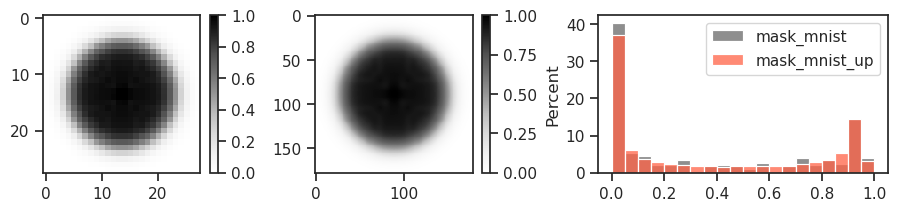

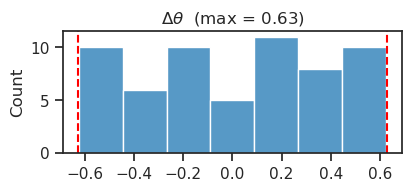

In [5]:
delta_theta = 4.0
mnist_stim_dim = 28
celeba_stim_dim = 178
celeba_delta_theta = (
    delta_theta *
    mnist_stim_dim /
    celeba_stim_dim
)

mask_mnist, mask_mnist_up = _make_mnist_mask(celeba_stim_dim)
feeder_celeba = _prep_celeba_data(
    new_delta_theta=celeba_delta_theta,
    mask=mask_mnist_up,
)

## Load model (MNIST)

In [6]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)', 'kms-(256,8,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'gaussian+logistic_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_chewie-0_(2025_09_1
5,17:58)',
    'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_17,16:
45)',
    'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_chewie-0_(2025_09_15,17
:57)',
    'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_yoru-0_(2025_09_17,16:47)',
    'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_17,11:12)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_17,16:46)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_dtheta-15_yoru-0_(2025_09_09,1
4:07)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_11,10:20)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_11,12:21)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_yoru-0_(2025_09_13,10:02)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_14,15:35)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_reattach-u0_mach-0_(2025_09_1
5,17:10)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-2_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_12,18:09)'
]

In [7]:
selected_models = {
    'poisson': 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_reattach-u0_mach-0_(2025_09_15,17:10)',
    'gaussian': 'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_17,11:12)',
    'gaussian+relu': 'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_chewie-0_(2025_09_15,17:57)',
    'gaussian+logistic': 'gaussian+logistic_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-prob_chewie-0_(2025_09_15,17:58)',
}
trainers = {
    name: load_model_lite(pjoin(root, f), device=device)[0]
    for name, f in selected_models.items()
}

## OOD: MNIST -> CelebA

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_temp(0.05)_gr(250)_(2025_09_15,17:10)

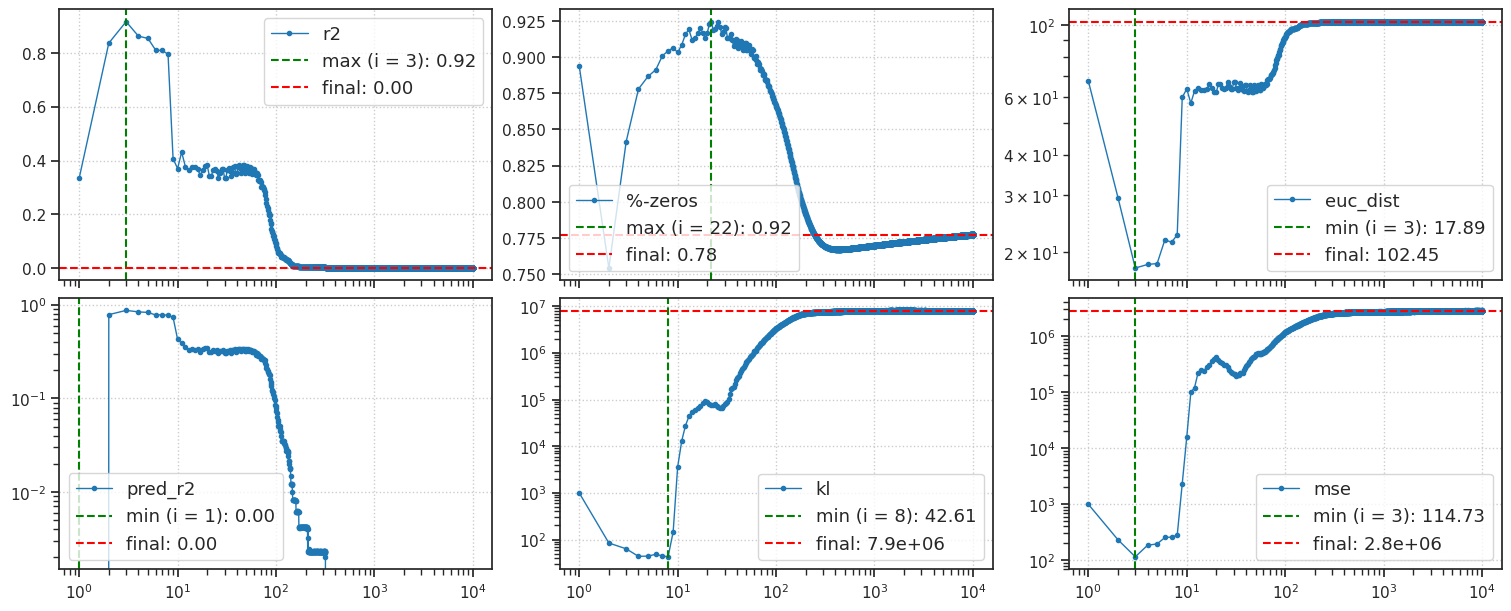

----------------------------------------------------------------------------------------------------

gaussian_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_17,11:12)

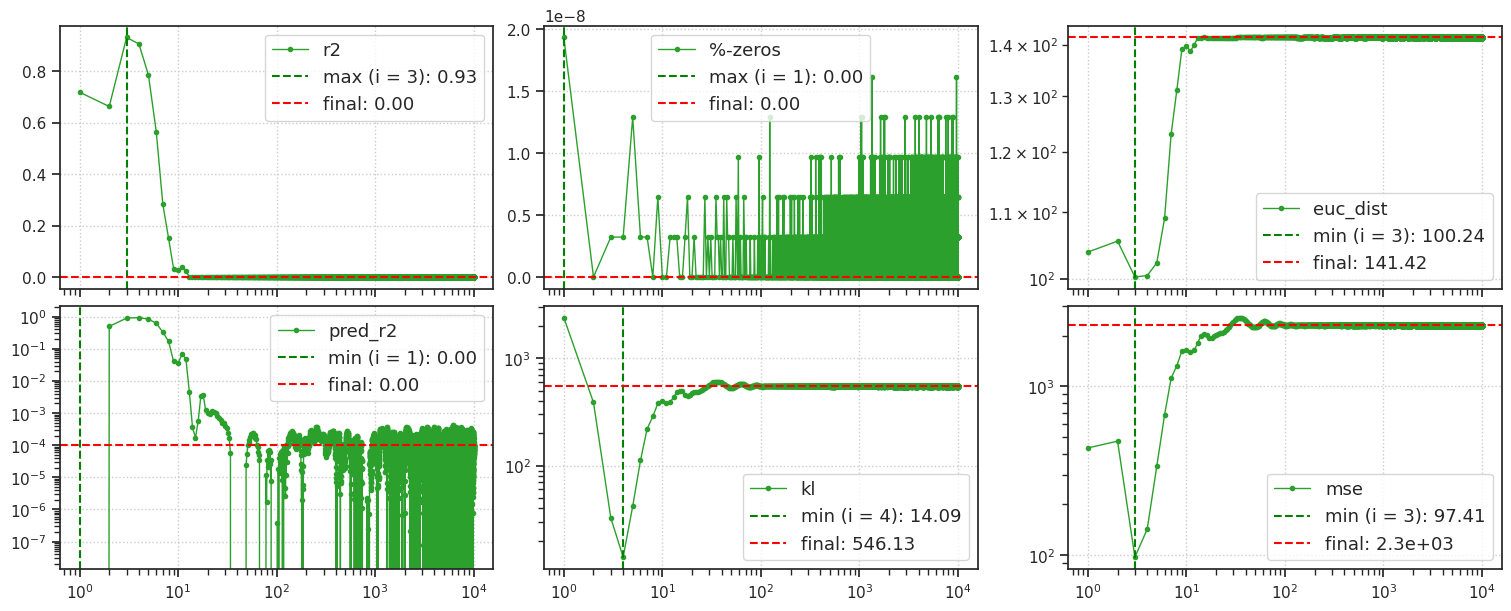

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_15,17:57)

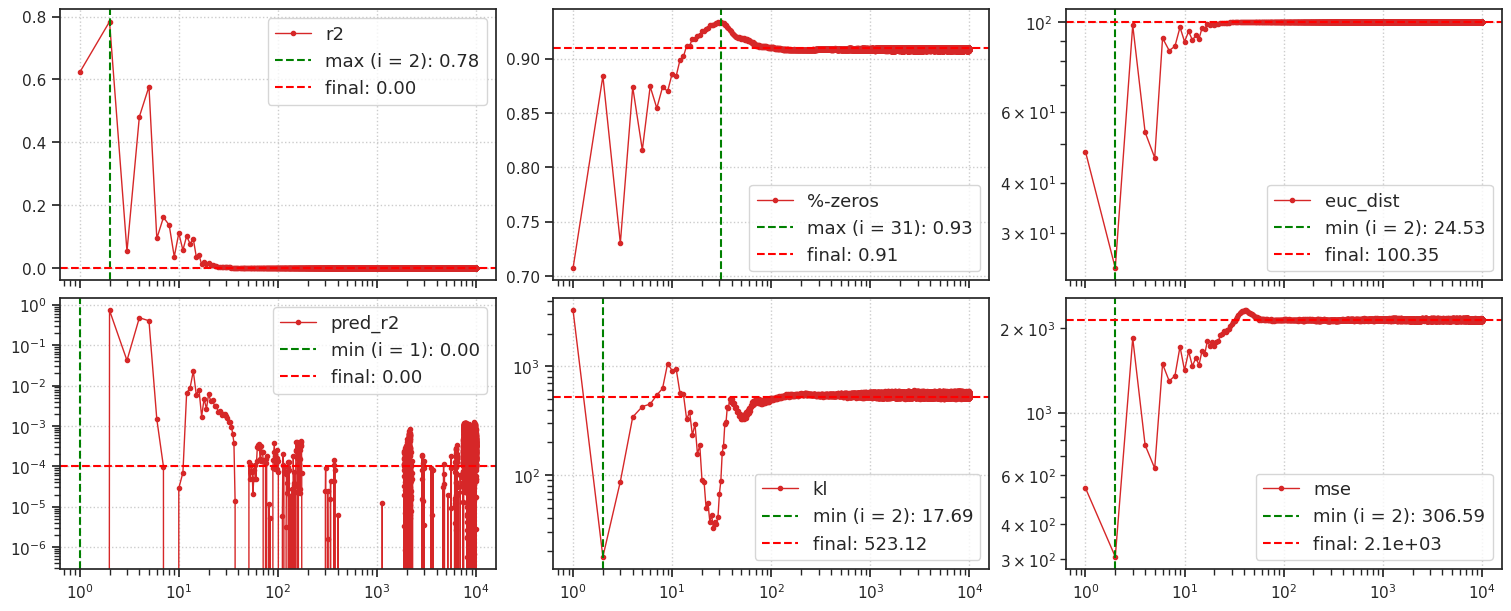

----------------------------------------------------------------------------------------------------

gaussian+logistic_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_15,17:58)

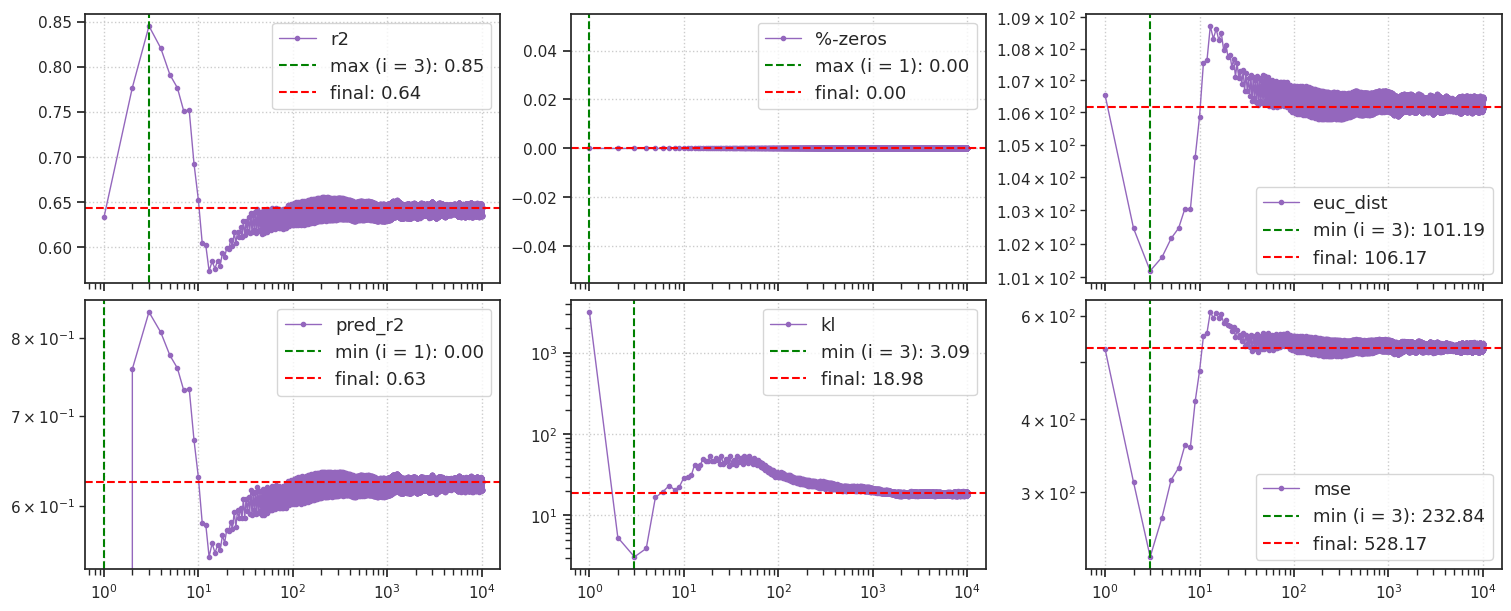

----------------------------------------------------------------------------------------------------

CPU times: user 4h 48min 29s, sys: 7.08 s, total: 4h 48min 36s
Wall time: 4h 48min 33s


In [8]:
%%time


for name, tr in trainers.items():
    tr.print()
    
    tr.model.update_model_dims(celeba_stim_dim)

    feeder_celeba.set_epoch(0)
    feeder_celeba.set_batch_data(0)
    
    results = tr.analysis(feeder_celeba, t_total=10_000, n_data_batches=-1, verbose=False)
    _ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])
    print('\n', '-' * 100, '\n\n')

In [7]:
from analysis.final import get_root_path

fit_poisson_mse = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_08,18:47)'
tr = load_model_lite(pjoin(get_root_path(), fit_poisson_mse), device=device)[0]

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_mse_<ngd|lin>
b200-ep100-lr(0.0005)_temp(0.05)_gr(250)_(2025_09_08,18:47)

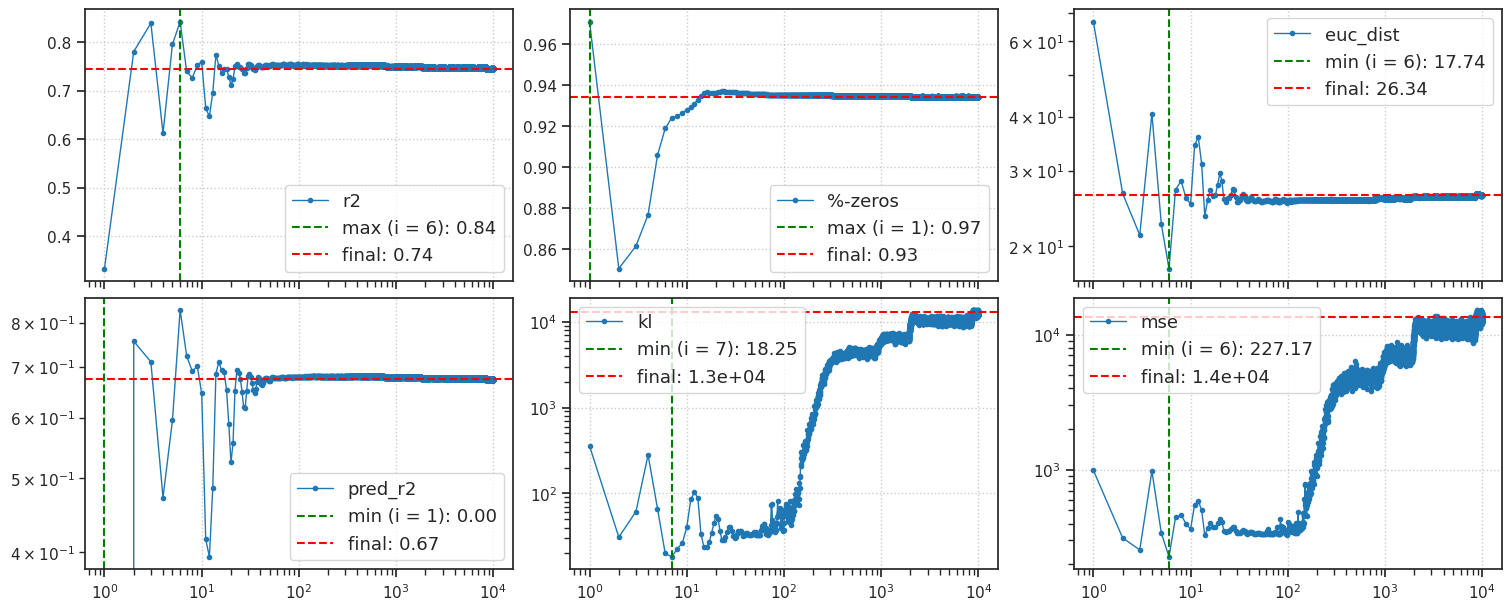

----------------------------------------------------------------------------------------------------

CPU times: user 27min 26s, sys: 879 ms, total: 27min 27s
Wall time: 27min 27s


In [10]:
%%time


tr.print()

tr.model.update_model_dims(celeba_stim_dim)

feeder_celeba.set_epoch(0)
feeder_celeba.set_batch_data(0)

results = tr.analysis(feeder_celeba, t_total=10_000, n_data_batches=-1, verbose=False)
_ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])
print('\n', '-' * 100, '\n\n')

In [8]:
from analysis.final import get_root_path

fit_guas_mse = 'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_yoru-0_(2025_09_17,16:47)'
tr = load_model_lite(pjoin(get_root_path(), fit_guas_mse), device=device)[0]

gaussian_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_mse_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_17,16:47)

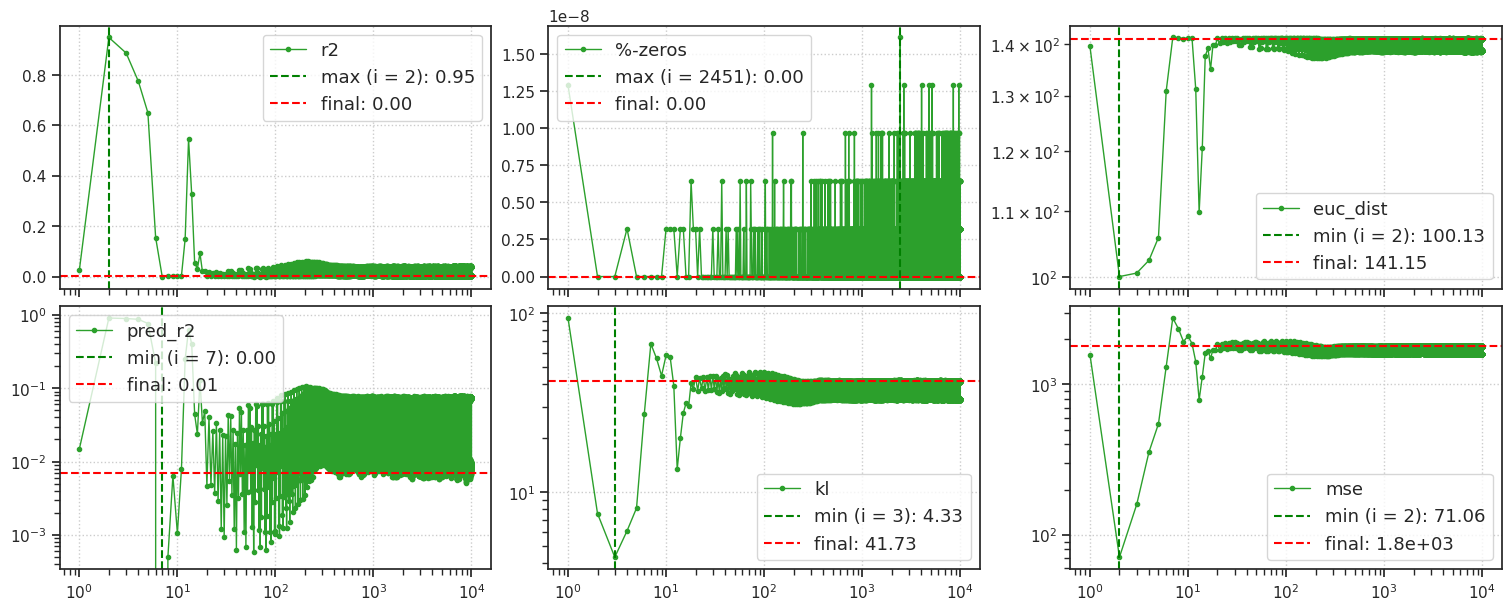

----------------------------------------------------------------------------------------------------

CPU times: user 1h 19min 22s, sys: 1.78 s, total: 1h 19min 24s
Wall time: 1h 19min 23s


In [9]:
%%time


tr.print()

tr.model.update_model_dims(celeba_stim_dim)

feeder_celeba.set_epoch(0)
feeder_celeba.set_batch_data(0)

results = tr.analysis(feeder_celeba, t_total=10_000, n_data_batches=-1, verbose=False)
_ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])
print('\n', '-' * 100, '\n\n')

### K = 128 models

In [6]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)', 'kms-(128,8,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_18,15:
23)',
    'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_18,15:2
2)',
    'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_18,15:21)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-mse_dtheta-15_yoru-0_(2025_09_09,1
4:08)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_18,15:21)'
]

In [7]:
selected_models = {
    'poisson': 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_18,15:21)',
    'gaussian': 'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_18,15:21)',
    'gaussian+relu': 'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_18,15:22)',
    'gaussian+relu+mse': 'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_18,15:23)',
}
trainers = {
    name: load_model_lite(pjoin(root, f), device=device)[0]
    for name, f in selected_models.items()
}

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_temp(0.05)_gr(250)_(2025_09_18,15:21)

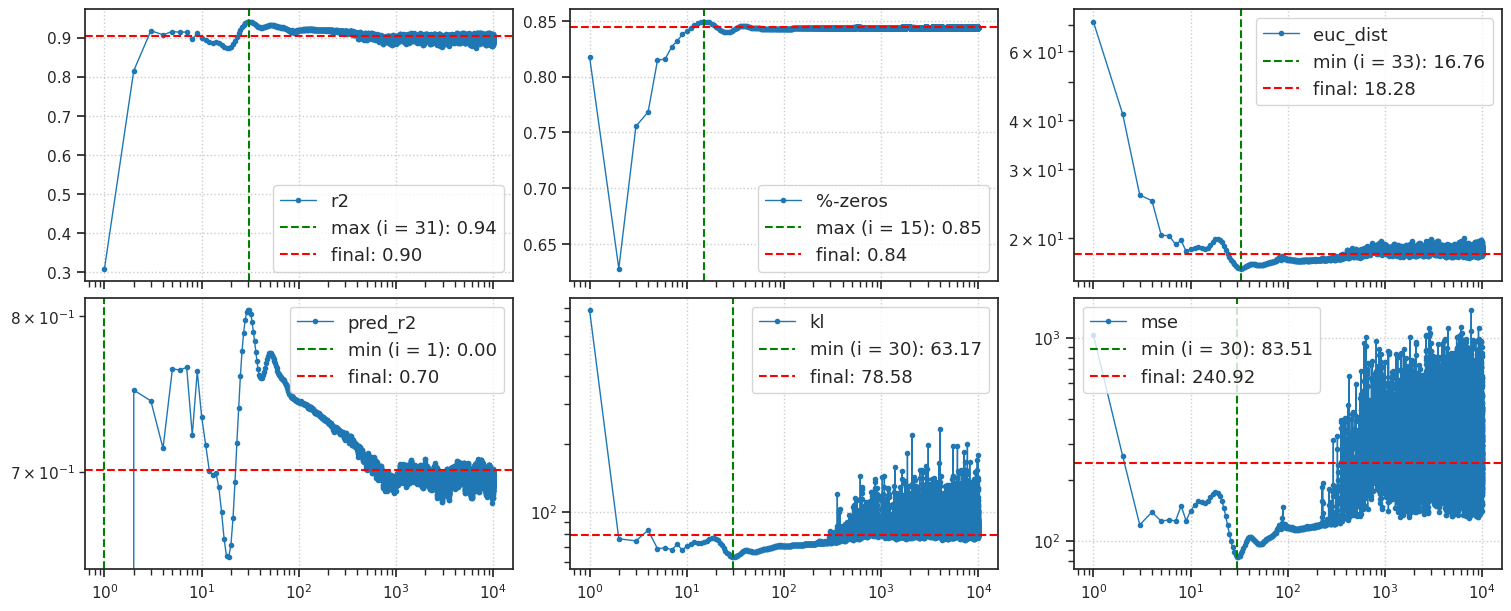

----------------------------------------------------------------------------------------------------

gaussian_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_18,15:21)

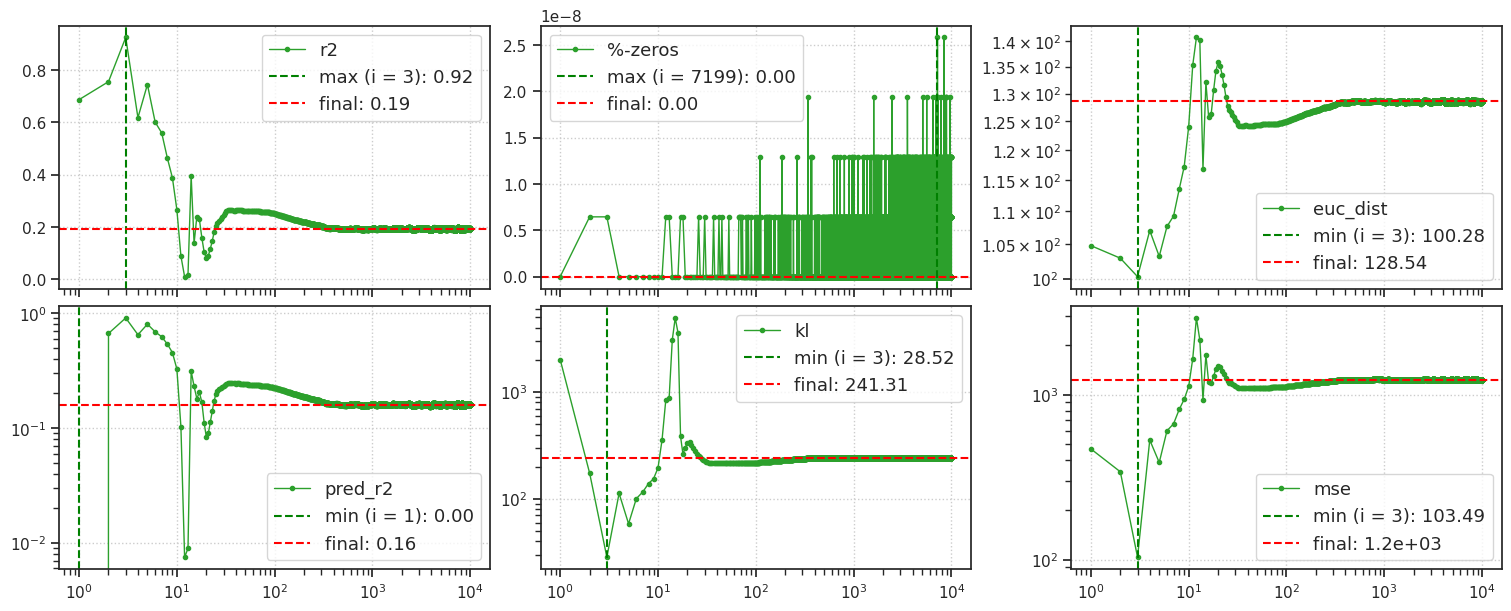

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_18,15:22)

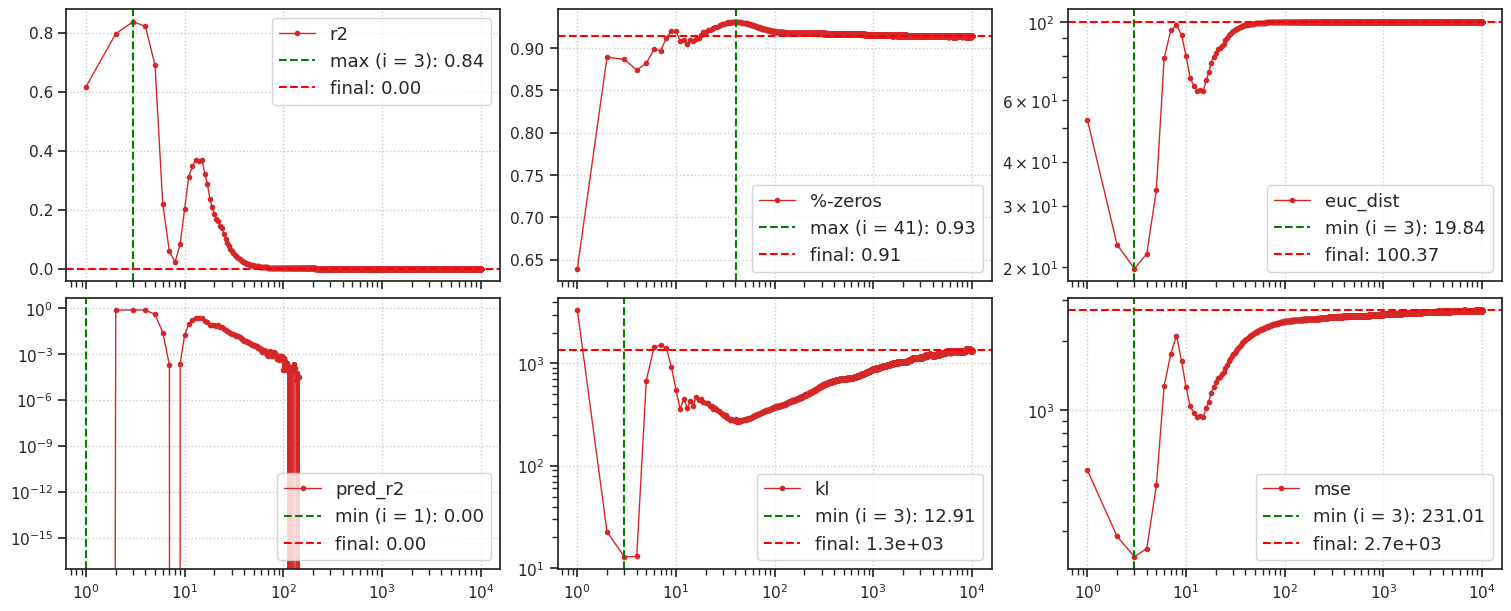

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_mse_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_18,15:23)

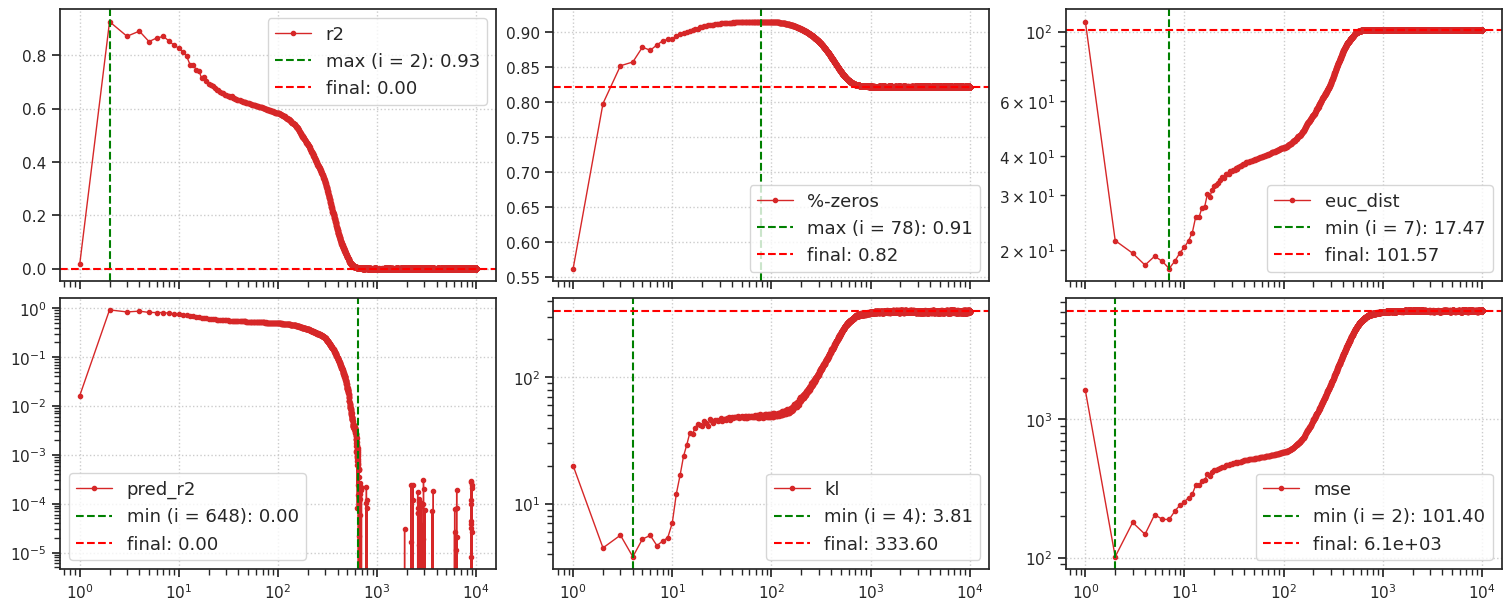

----------------------------------------------------------------------------------------------------

CPU times: user 1h 52min 20s, sys: 2.94 s, total: 1h 52min 23s
Wall time: 1h 52min 22s


In [12]:
%%time


for name, tr in trainers.items():
    tr.print()
    
    tr.model.update_model_dims(celeba_stim_dim)

    feeder_celeba.set_epoch(0)
    feeder_celeba.set_batch_data(0)
    
    results = tr.analysis(feeder_celeba, t_total=10_000, n_data_batches=-1, verbose=False)
    _ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])
    print('\n', '-' * 100, '\n\n')

## Sanity check for the loaded models

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_temp(0.05)_gr(250)_(2025_09_18,15:21)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:06<00:00,  3.16s/it]


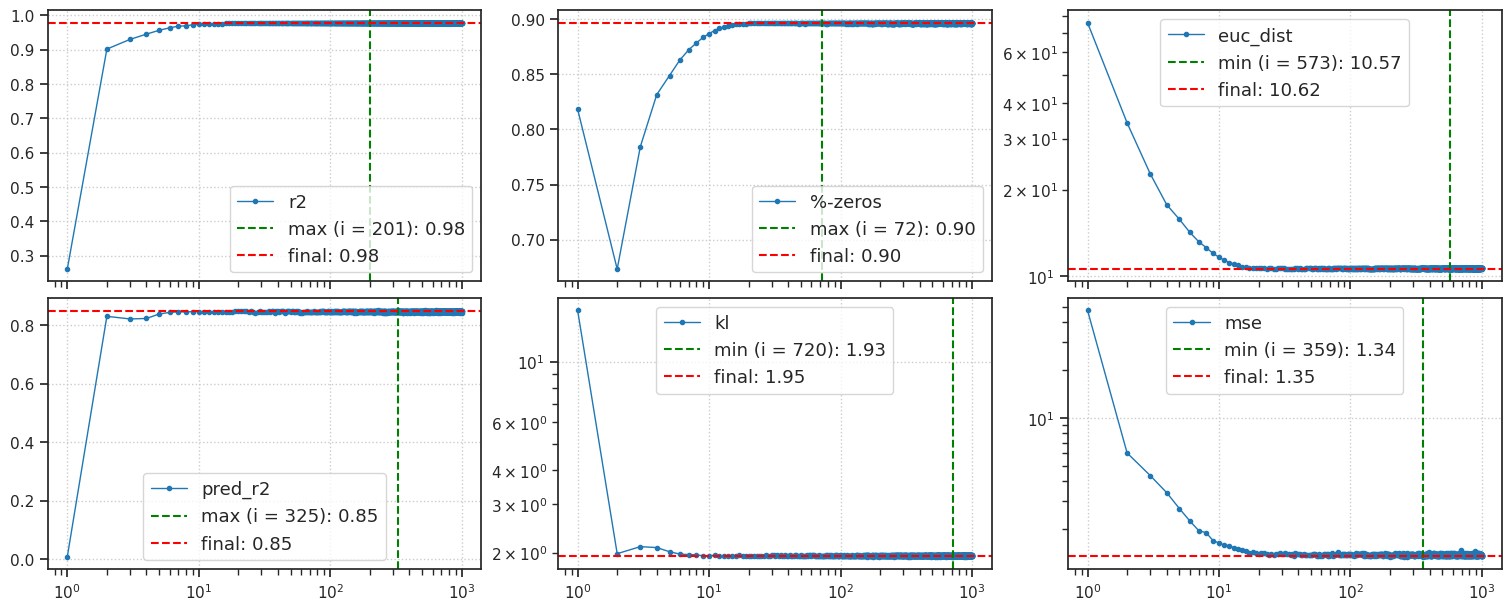

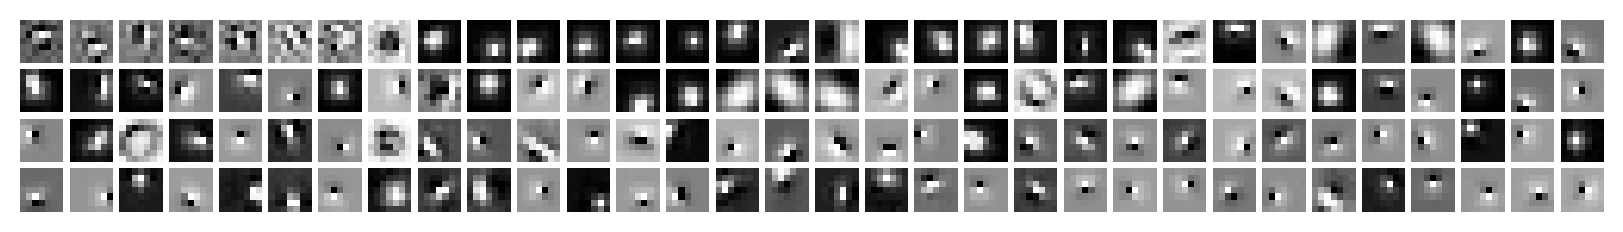

dt_enc = 0.107,   dt_fwd = 0.767

----------------------------------------------------------------------------------------------------

gaussian_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_18,15:21)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:05<00:00,  2.70s/it]


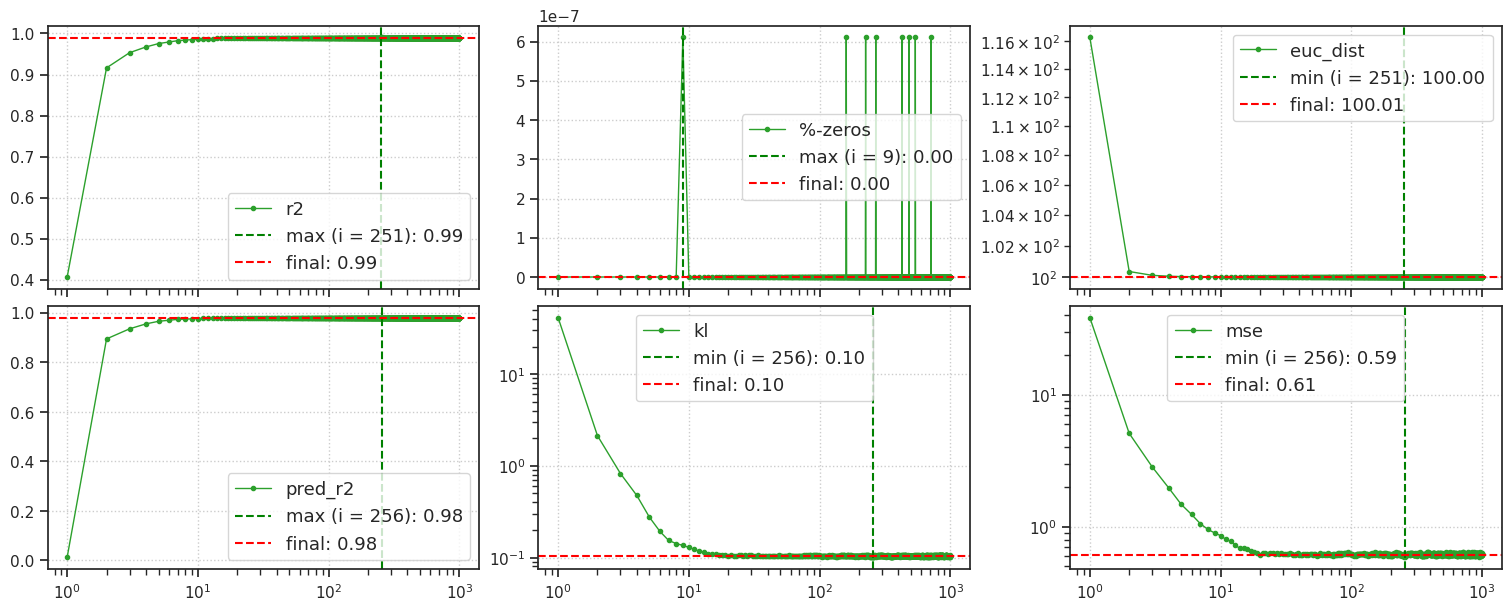

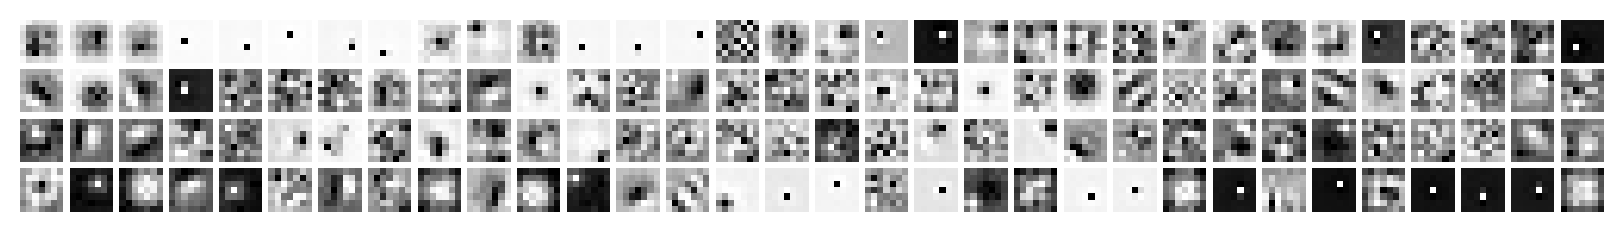

dt_enc = 3.134,   dt_fwd = 1.207

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_18,15:22)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:05<00:00,  2.74s/it]


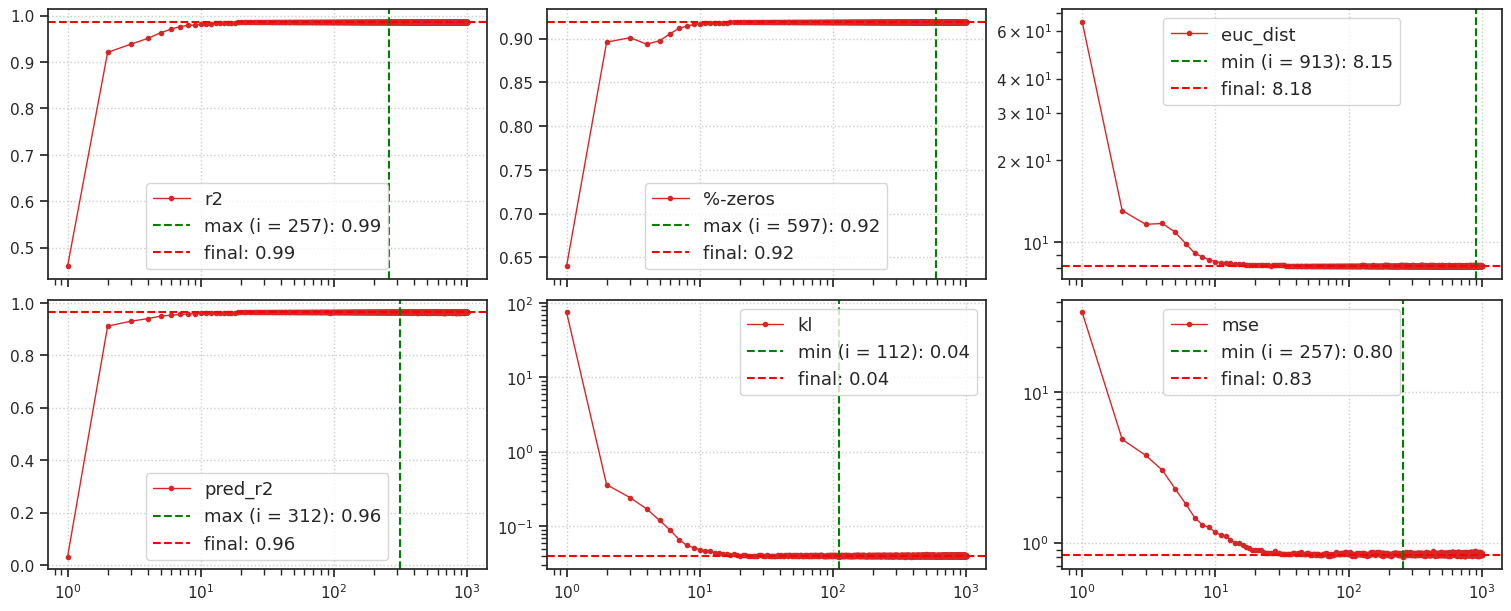

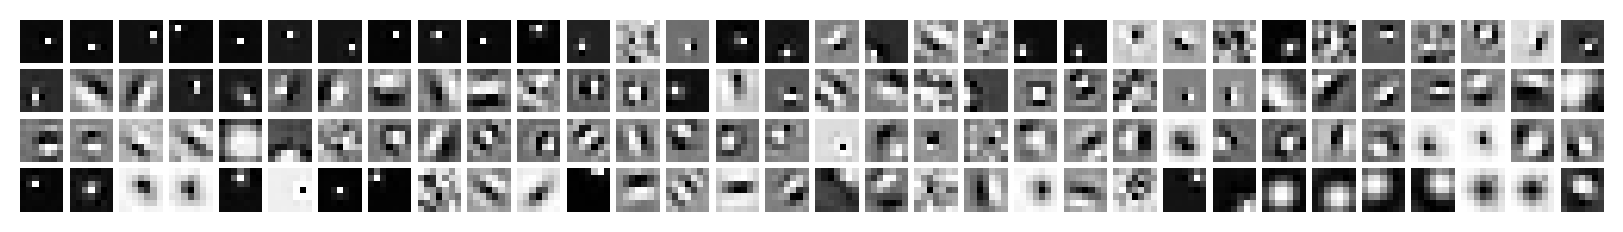

dt_enc = 0.602,   dt_fwd = 4.494

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(128,8,3)_fwd-(3,7)_mse_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_18,15:23)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:05<00:00,  2.69s/it]


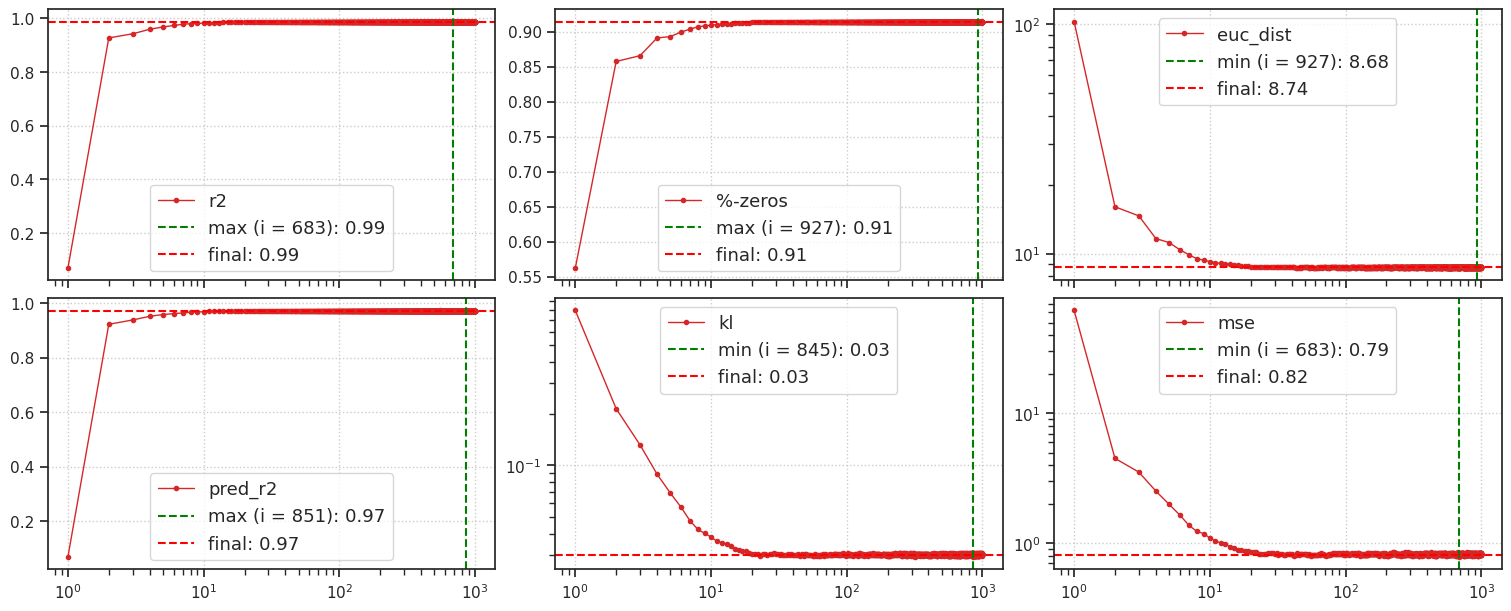

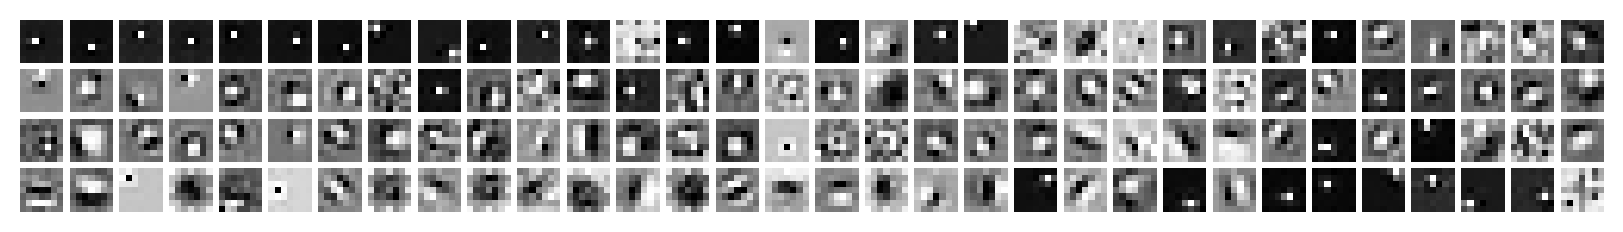

dt_enc = 3.543,   dt_fwd = 6.587

----------------------------------------------------------------------------------------------------

In [8]:
for name, tr in trainers.items():
    tr.print()

    results = tr.analysis('vld', t_total=1000, n_data_batches=2)
    _ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])

    tr.model.show(order='u0')
    dt_str = ',\t  '.join([
        f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
        f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
    ])
    print(dt_str)
    print('\n', '-' * 100, '\n\n')

### K = 64 models

In [13]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)', 'kms-(64,8,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'gaussian+logistic_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_yoru-0_(2025_09_19,1
7:13)',
    'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_19,17:12
)',
    'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_19,17:12)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_yoru-0_(2025_09_19,17:14)'
]

In [14]:
selected_models = {
    'poisson': 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_yoru-0_(2025_09_19,17:14)',
    'gaussian': 'gaussian_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_19,17:12)',
    'gaussian+relu': 'gaussian+relu_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_mach-0_(2025_09_19,17:12)',
    'gaussian+logistic': 'gaussian+logistic_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_recon-prob_yoru-0_(2025_09_19,17:13)',
}
trainers = {
    name: load_model_lite(pjoin(root, f), device=device)[0]
    for name, f in selected_models.items()
}

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_temp(0.05)_gr(250)_(2025_09_19,17:14)

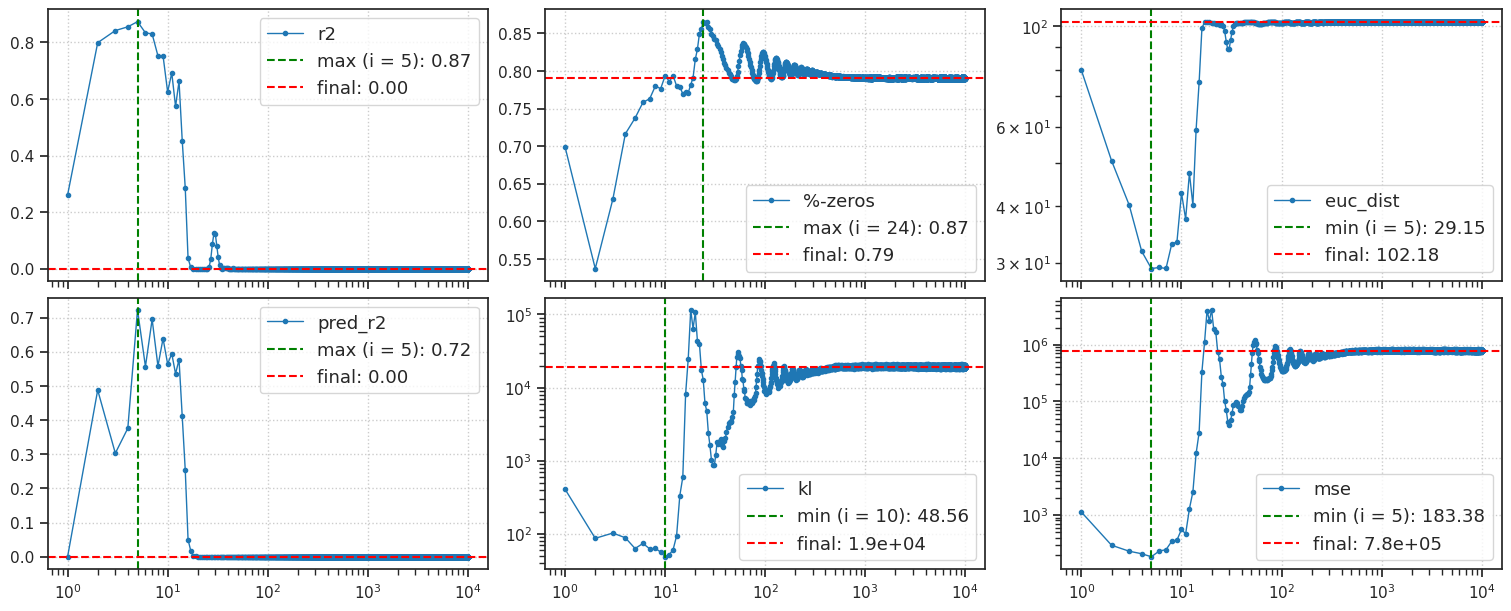

----------------------------------------------------------------------------------------------------

gaussian_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_19,17:12)

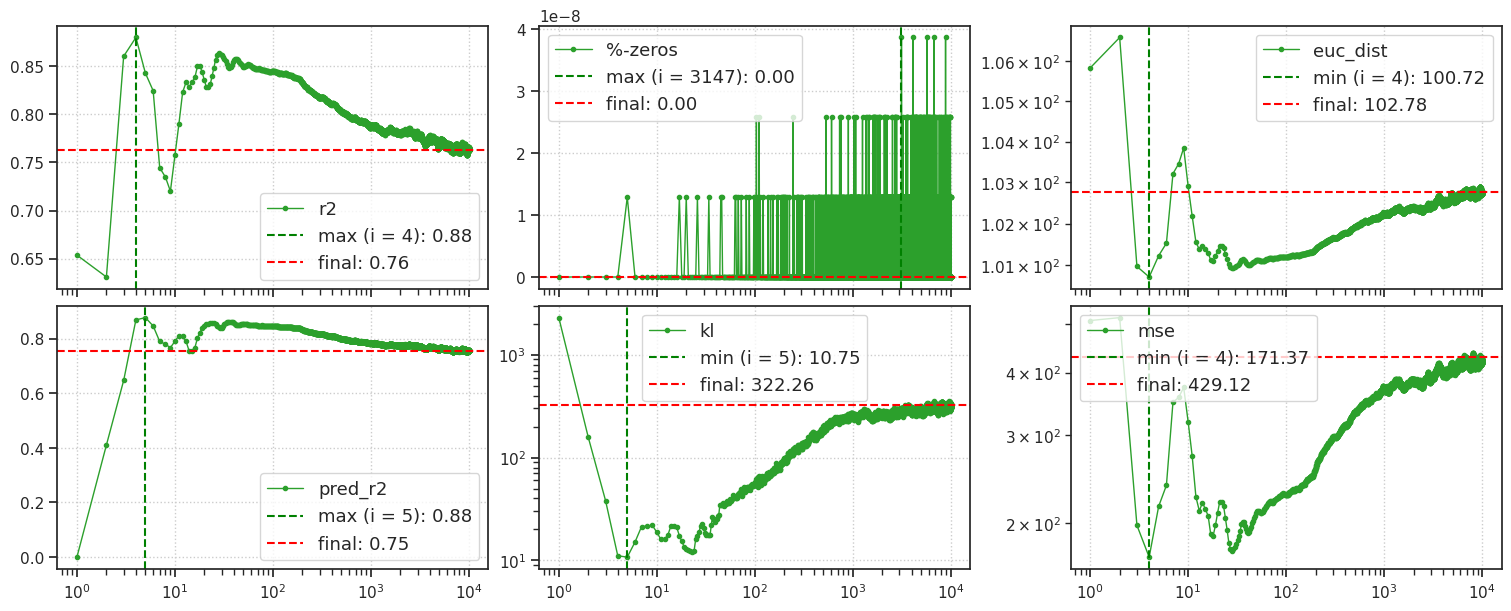

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_19,17:12)

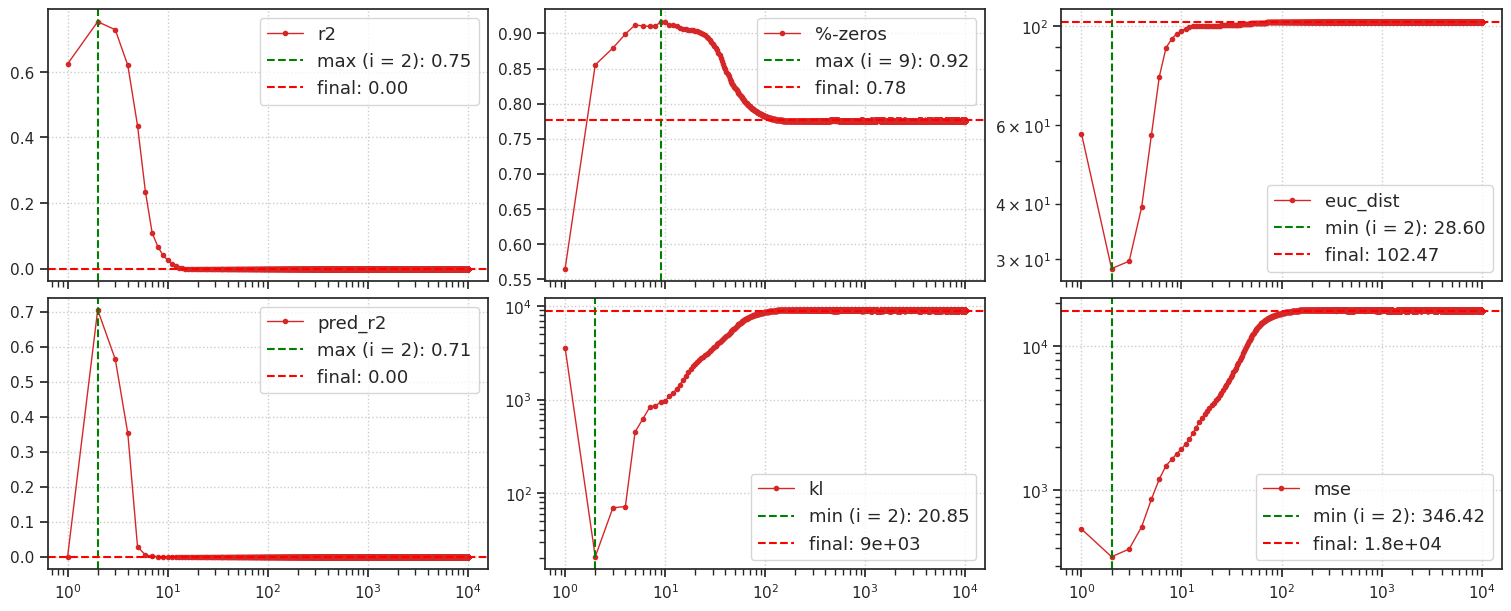

----------------------------------------------------------------------------------------------------

gaussian+logistic_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_19,17:13)

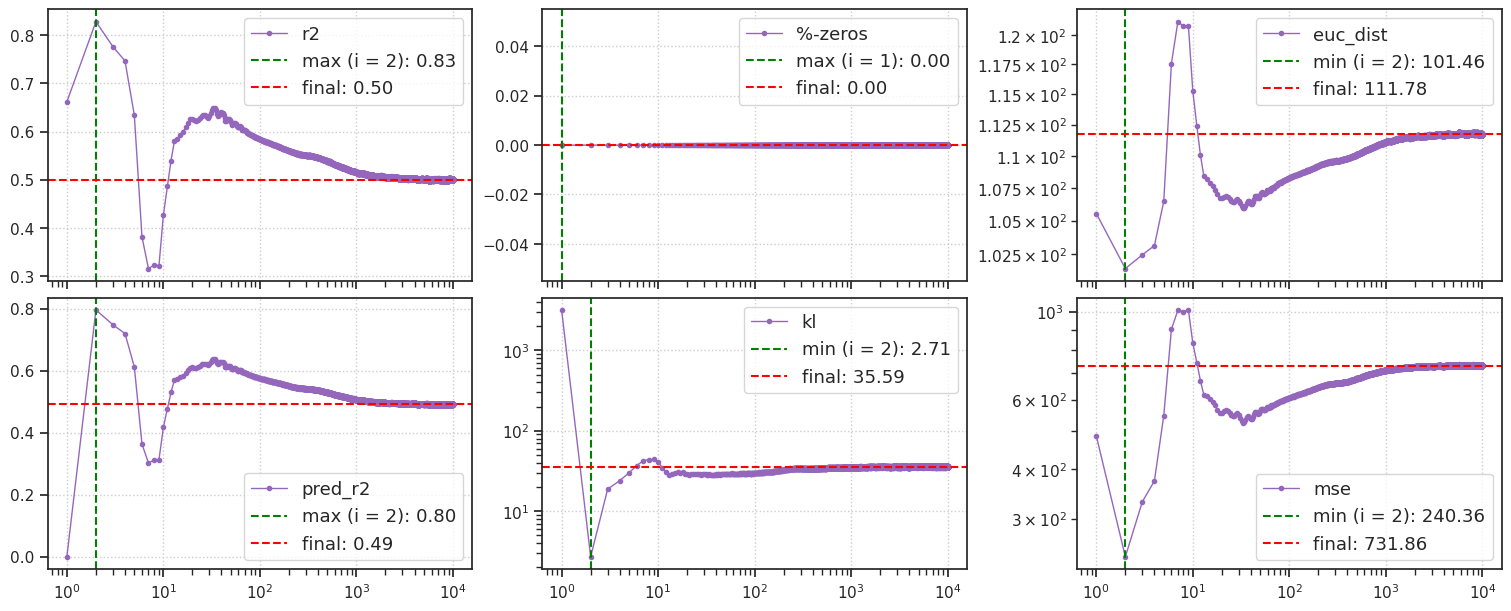

----------------------------------------------------------------------------------------------------

CPU times: user 45min 30s, sys: 1.15 s, total: 45min 31s
Wall time: 45min 31s


In [11]:
%%time


for name, tr in trainers.items():
    tr.print()
    
    tr.model.update_model_dims(celeba_stim_dim)

    feeder_celeba.set_epoch(0)
    feeder_celeba.set_batch_data(0)
    
    results = tr.analysis(feeder_celeba, t_total=10_000, n_data_batches=-1, verbose=False)
    _ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])
    print('\n', '-' * 100, '\n\n')

## Sanity check for the loaded models

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_temp(0.05)_gr(250)_(2025_09_19,17:14)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:06<00:00,  3.11s/it]


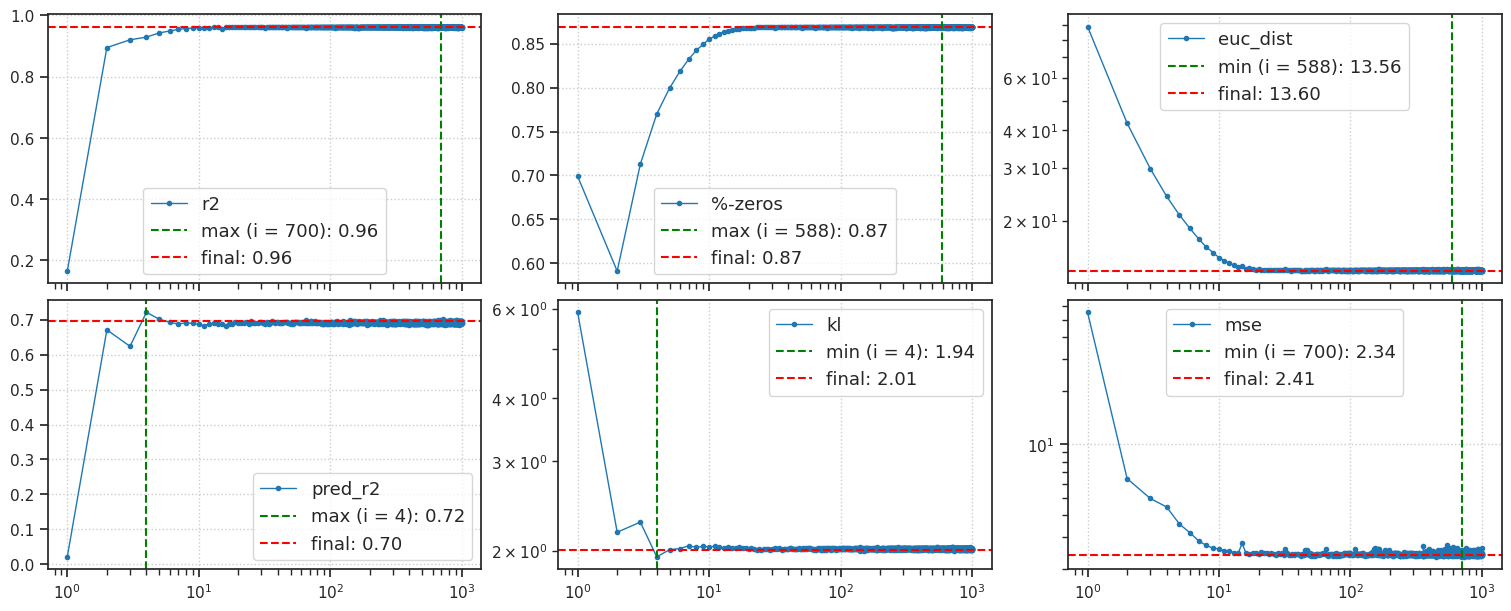

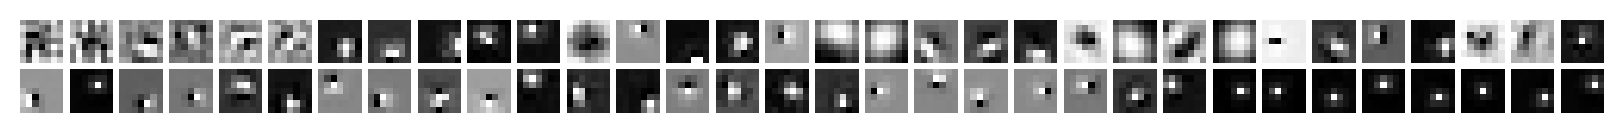

dt_enc = 0.066,   dt_fwd = 1.310

----------------------------------------------------------------------------------------------------

gaussian_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_19,17:12)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:05<00:00,  2.83s/it]


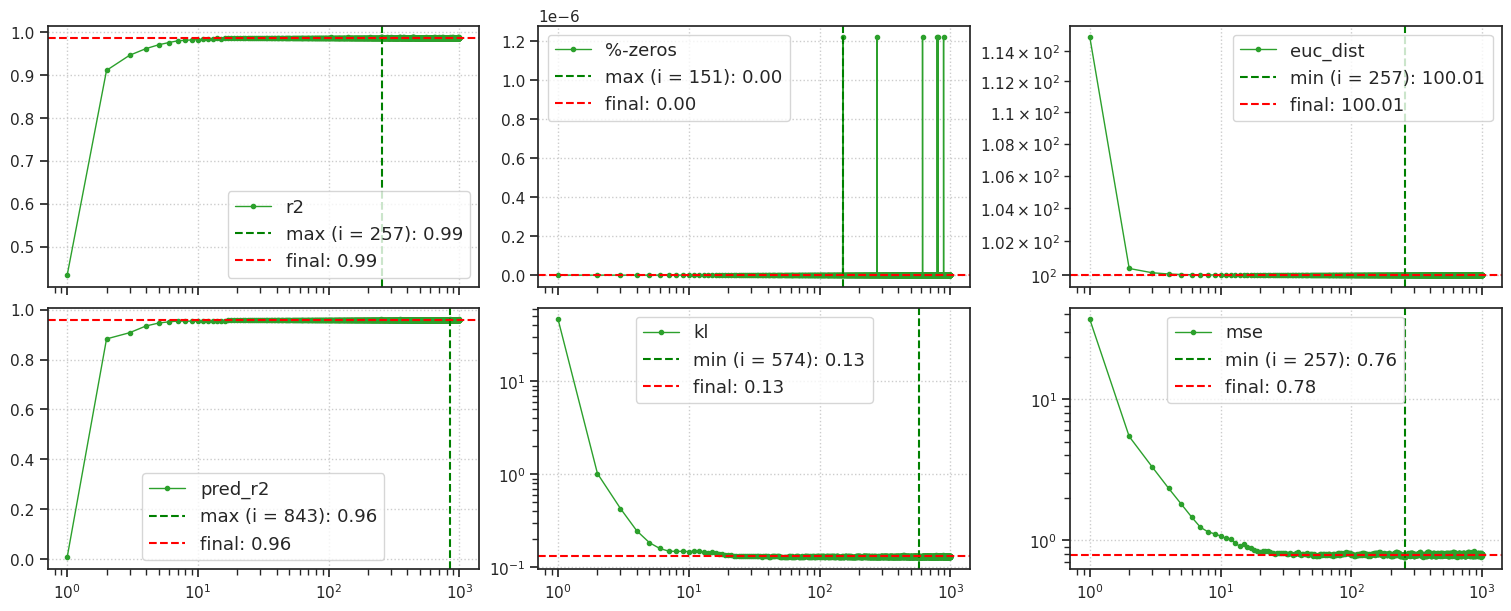

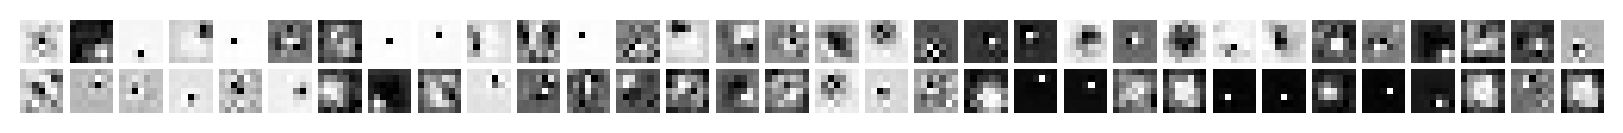

dt_enc = 1.887,   dt_fwd = 1.975

----------------------------------------------------------------------------------------------------

gaussian+relu_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_19,17:12)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:05<00:00,  2.93s/it]


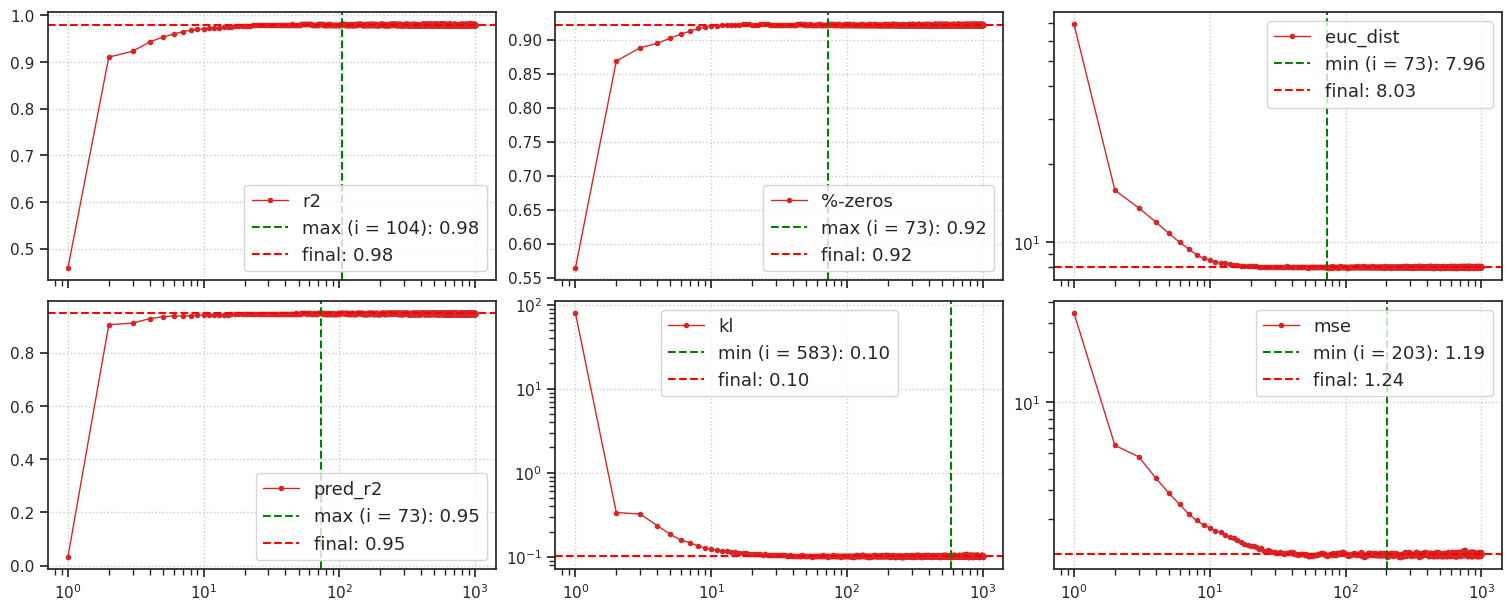

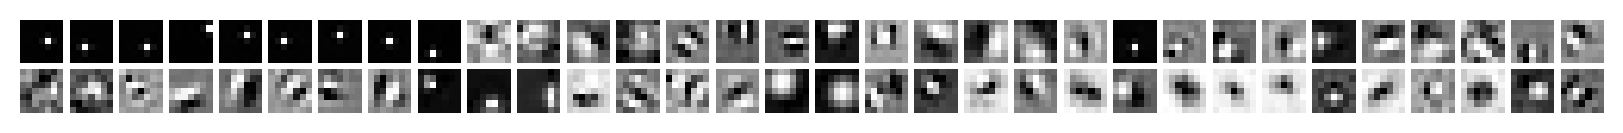

dt_enc = 0.650,   dt_fwd = 4.282

----------------------------------------------------------------------------------------------------

gaussian+logistic_MNIST+rotate_t-(16,8,4)_b-1_kms-(64,8,3)_fwd-(3,7)_prob_<ngd|lin>
b100-ep100-lr(0.0008)_gr(250)_(2025_09_19,17:13)

batch #2, (t = 1000): 100%|█████████████| 2/2 [00:05<00:00,  2.86s/it]


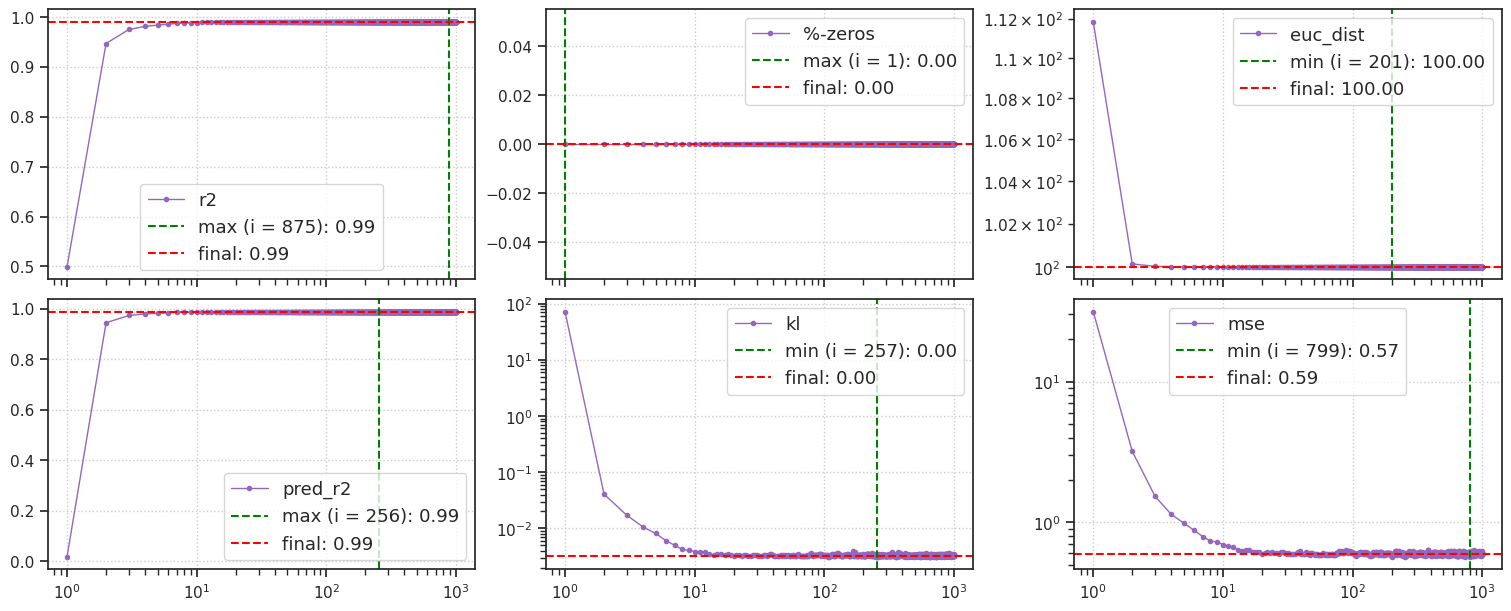

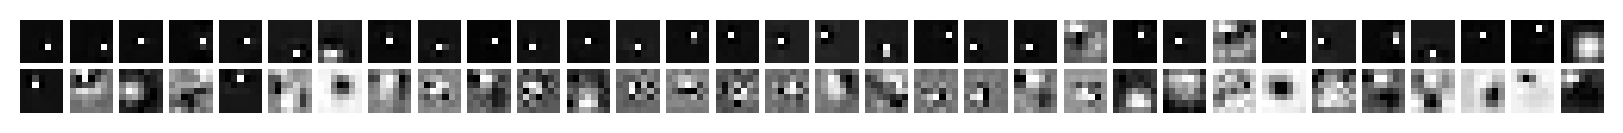

dt_enc = 0.642,   dt_fwd = 3.956

----------------------------------------------------------------------------------------------------

In [15]:
for name, tr in trainers.items():
    tr.print()

    results = tr.analysis('vld', t_total=1000, n_data_batches=2)
    _ = plot_convergence(results=results, color=pal[tr.model.cfg.str_model])

    tr.model.show(order='u0')
    dt_str = ',\t  '.join([
        f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
        f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
    ])
    print(dt_str)
    print('\n', '-' * 100, '\n\n')

## From old notebook

But useful

In [35]:
# selected_incides = [115, 6, 53, 4, 328, 153, 318, 255, 256, 185]
selected_incides = [115, 6, 53, 4, 328, 153, 318, 255, 256, 185]
r2_samples[selected_incides]

array([-1.0792241e+03,  9.3437189e-01,  9.1312343e-01, -1.0566971e+03,
       -8.5807233e+02, -7.2292377e+02,  9.3188328e-01,  9.4205397e-01,
       -9.2115869e+02, -1.2977791e+03], dtype=float32)

In [36]:
true_to_anim = output['true'][selected_incides]
recon_to_anim = output['recon'][selected_incides]

true_to_anim, recon_to_anim = filter_boundaries(
    [true_to_anim, recon_to_anim],
    mask=mask_mnist_up > mask_thres,
)

true_to_anim.shape, recon_to_anim.shape

((10, 1000, 1, 138, 138), (10, 1000, 1, 138, 138))

In [37]:
np.quantile(true_to_anim.ravel(), 0.99), np.quantile(recon_to_anim.ravel(), 0.99)

(0.8551976084709167, 11.006916093826248)

In [38]:
mp4_file_name = '_'.join([
    f"{tr.model.cfg.dataset}-to-CelebA{true_to_anim.shape[-1]}",
    f"ids-{set(selected_incides)}".replace(', ', ','),
    tr.model.cfg.str_kms,
    tr.model.cfg.str_fwd,
    f"dtheta-{tr.model.cfg.feeder_cfg['max_delta_theta']}",
])
mp4_file_name = f"{mp4_file_name}.mp4"

print(mp4_file_name)

MNIST+rotate-to-CelebA138_ids-{256,185,4,6,328,115,53,153,318,255}_kms-(512,58,3)_fwd-(1,3)_dtheta-4.0.mp4

[DONE] animation saved:
/home/hadi/Dropbox/git/jb-progress-2025/tmp/animations/ood/MNIST+rotate-to-CelebA138_ids-{256,185,4,6,328,115,53,15
3,318,255}_kms-(512,58,3)_fwd-(1,3)_dtheta-4.0.mp4

CPU times: user 54.3 s, sys: 632 ms, total: 54.9 s
Wall time: 55.6 s


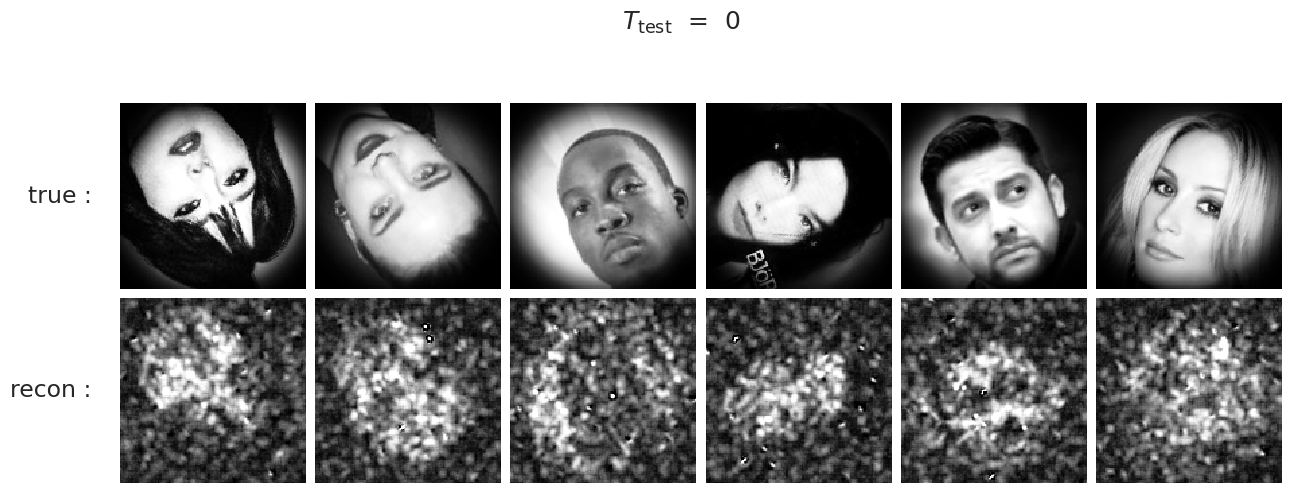

In [40]:
%%time


_ = animate_recons(
    save_file=pjoin(anim_dir, mp4_file_name),
    recon=recon_to_anim,
    true=true_to_anim,
    n_samples=6,
    vmin=0.0,
    vmax=0.85,
    figsize=(15.0, 5.5),
    # dry_run=True,
    dpi=100,
)